# <span style="color:darkblue"> Lecture 16 - Time Data </span>

<font size = "5">

In  the last lecture we ...
- Completed the module on SQL
- Learned about escape characters


In  this lecture we will ...

- Process time data in Python
- Learn about wildcards

# <span style="color:darkblue"> I. Import Libraries and Data </span>

<font size = "5">

Import libraries

In [1]:
# "pandas" processes datasets
# "maplotlib.pyplot" generates graphs
# "maplotlib.dates" has advanced options for plotting dates
# "datetime" handles date information

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import date, time, datetime

<font size = "5">

Import data

In [2]:
financial = pd.read_csv("data_raw/financial.csv")

<font size = "5">

"Parse" time columns

In [3]:
# Convert string column to datetime format
# If the date format is simple, you can also parse on input as
# financial = pd.read_csv("data_raw/financial.csv",parse_dates = ["date"]
# See advanced options for parsing further in the lecture...

financial["date"] = pd.to_datetime(financial["date_str"])

<font size = "5">

Check Types

In [4]:
# Standard data types are "int", "str", "float", and "bool"
# There is also a "datetime" types

financial.dtypes

date_str            object
sp500              float64
djia               float64
date_ex1            object
date_ex2            object
date_ex3            object
date        datetime64[ns]
dtype: object

<font size = "5">

Visualize time data

In [5]:
financial['date'][0]

Timestamp('2018-04-04 00:00:00')

In [6]:
financial.sort_values("date",ascending = False)

,date_str,sp500,djia,date_ex1,date_ex2,date_ex3,date
1304,4/4/2023,4100.60,33402.38,April 04 2023,"Tuesday, 2023-04-04",4-Apr-23,2023-04-04
1303,4/3/2023,4124.51,33601.15,April 03 2023,"Monday, 2023-04-03",3-Apr-23,2023-04-03
1302,3/31/2023,4109.31,33274.15,March 31 2023,"Friday, 2023-03-31",31-Mar-23,2023-03-31
1301,3/30/2023,4050.83,32859.03,March 30 2023,"Thursday, 2023-03-30",30-Mar-23,2023-03-30
1300,3/29/2023,4027.81,32717.60,March 29 2023,"Wednesday, 2023-03-29",29-Mar-23,2023-03-29
...,...,...,...,...,...,...,...
4,4/10/2018,2656.87,24408.00,April 10 2018,"Tuesday, 2018-04-10",10-Apr-18,2018-04-10
3,4/9/2018,2613.16,23979.10,April 09 2018,"Monday, 2018-04-09",9-Apr-18,2018-04-09
2,4/6/2018,2604.47,23932.76,April 06 2018,"Friday, 2018-04-06",6-Apr-18,2018-04-06
1,4/5/2018,2662.84,24505.22,April 05 2018,"Thursday, 2018-04-05",5-Apr-18,2018-04-05


Text(0.5, 1.0, 'The evolution of the stock market')

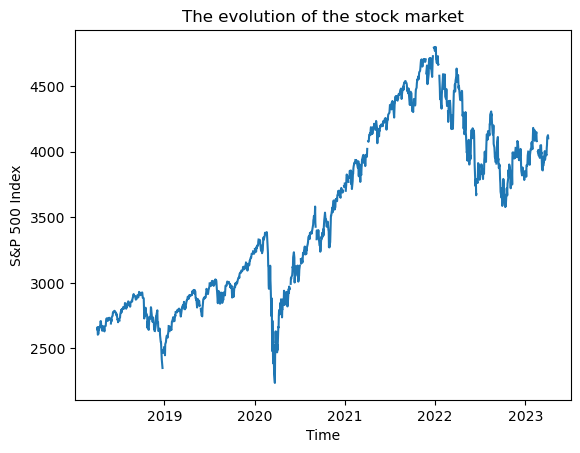

In [7]:
# plt.plot() is used to create line plots
# The first two arguments are column names for the (x,y) data
# The third argument is the data
# Make sure that the data is sorted, since the lines will be connected
# based on the order of the dataset

plt.plot("date", "sp500",
          data = financial)
plt.xlabel("Time")
plt.ylabel("S&P 500 Index")
plt.title("The evolution of the stock market")


<font size = "5">

S&P 500 tracks the average performance of <br>
of the largest companies in the US stock market

$\quad$ https://en.wikipedia.org/wiki/S%26P_500 <br>
$\quad$ https://fred.stlouisfed.org/series/SP500

<font size = "5">

Try it yourself!

- Generate a line plot which has the Dow Jones <br>
Industrial Index ("djia") on the y-axis and <br>
"date" on the x-axis.

Text(0.5, 1.0, 'Dow Jones Industrial Index')

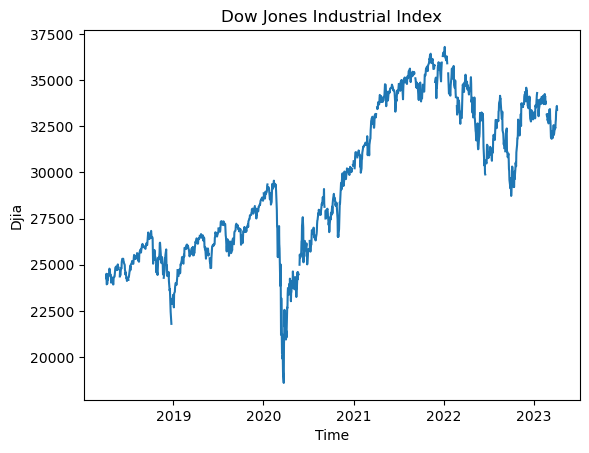

In [9]:
# Write your own code

plt.plot("date", "djia",
          data = financial)
plt.xlabel("Time")
plt.ylabel("Djia")
plt.title("Dow Jones Industrial Index")


# <span style="color:darkblue"> II. Dates + Wild Cards  </span>

<font size = "5">

Convert to string (a)


- A wildcard ```%``` is used to denote date formats
- Useful when working with text data

$\quad$ <img src="figures/wildcards_fig1.png" alt="drawing" width="300"/>

In [10]:
# "String from time" .dt.strftime()
# The first argument needs to be a datetime type 
# The second argument is the format you want to use
# Note: "dt" stands for datatime

financial["month_str"] = financial["date"].dt.strftime("%m")
financial["week_str"]  = financial["date"].dt.strftime("%W")


<font size = "5">

Convert to string (b)

$\quad$ <img src="figures/wildcards_fig2.png" alt="drawing" width="400"/>

In [11]:
financial["monthname"]   =  financial["date"].dt.strftime("%B")
financial["weekdayname"] =  financial["date"].dt.strftime("%A")

<font size = "5">

Personalized format

In [12]:
# Insert wildcards inside custom strings
# Internally it will "fill-in-the-blank" with the corresponding information
# You can use commas, dashes (--), slash (/) or other characters

message_monthname =  financial["date"].dt.strftime("This is the month of %B")
message_monthday  =  financial["date"].dt.strftime("The day of the week is %A")
message_yearmonth =  financial["date"].dt.strftime("%Y-%m")


<font size = "5">

Try it yourself!

- Create a new column called "date_test" <br>
  which has the format using ```.dt.strftime()```
  
$\quad$ ```Monday, December 31, 2023 ```

In [14]:
# Write your own code

# Ensure the date column is in datetime format
financial['date'] = pd.to_datetime(financial['date'])

# Create the new column with the desired format
financial['date_test'] = financial['date'].dt.strftime('%A, %B %d, %Y')

# Display the first few rows to verify
print(financial[['date', 'date_test']].head())

        date                  date_test
0 2018-04-04  Wednesday, April 04, 2018
1 2018-04-05   Thursday, April 05, 2018
2 2018-04-06     Friday, April 06, 2018
3 2018-04-09     Monday, April 09, 2018
4 2018-04-10    Tuesday, April 10, 2018


# <span style="color:darkblue"> III. Data Operations </span>

<font size = "5">

Parsing + wild cards

$\quad$ <img src="figures/wildcards_fig3.png" alt="drawing" width="400"/>

In [15]:
# Combine wildcards + characters depending on the input
# Can include spaces, commas, "/", "-" or any other formatting
# Be careful to include the wildcar letters in upper or lower case 
# depending on the intended format 

financial['date_ex1_dt'] = pd.to_datetime(financial["date_ex1"], format = "%B %d %Y")
financial['date_ex2_dt'] = pd.to_datetime(financial["date_ex2"], format = "%A, %Y-%m-%d")


**Does the following line of code work?** ```pd.to_datetime(financial["date_ex1"], format = "%A, %Y-%m-%d")```

<font size = "5">

Period grouping

In [ ]:
# In "freq" specify the letter for the level of aggregation
# year (y), month (m), week (w), day(d)
# There are also more advanced options! See documentation

month_config = pd.Grouper(key='date', freq='y')

<font size = "5">

Aggregate by period

In [ ]:
financial.groupby(month_config).agg(sp500_mean = ("sp500","mean")).reset_index()

In [ ]:
# Group on the period column
# We use a wrapper () to split the command into multiple lines
# The ".reset_index()" option ensures that the grouper is
# converted to a column. This is important for plotting.
# There's a lot of options to 

monthlydata = (financial
               .groupby(month_config) 
               .agg(sp500_mean = ("sp500","mean"))
               .reset_index())

In [ ]:
monthlydata

<font size = "5">

Plot aggregate data

In [ ]:
plt.plot("date","sp500_mean",
          data = monthlydata)
plt.xlabel("Time")
plt.ylabel("S&P 500")
plt.title("Monthly average stock market performance")

<font size = "5">

Try it yourself!

- Practice ```pd.to_datetime()```
- Parse the column "data_ex3"
- Take a close look at the formatting

HINT: Refer to the table of wildcards <br>
 in the previous section


In [ ]:
# Write your own code



<font size = "5">



<font size = "5">

Try it yourself!

- Compute an aggregate dataset which computes the standard <br>
deviation of the S&P 500 at the weekly level.
- Generate a line plot with your results


In [ ]:
# Write your own code



# <span style="color:darkblue"> IV. Additional Material </span>

<font size = "5">

Full list of wild cards:

- More fine-grained, e.g. microseconds, etc.
- Other formats, e.g. time zone, "AM/PM", etc.

https://www.w3schools.com/python/python_datetime.asp